# Laboratorio 6 — Reconstrucción LAB4: Regresión Logística Binaria con Red Neuronal

Reconstrucción del **LAB4** (clasificación binaria malware vs benigna) usando **PyTorch**.
Dataset: NATICUSdroid (android permissions), m = 29 332, n = 86 features binarios.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from matplotlib import pyplot

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## 1. Carga y exploración del dataset

In [2]:
df = pd.read_csv('../../LAB4/data.csv')

print('Dimensiones:', df.shape)
print('Valores nulos:', df.isna().sum().sum())
print('\nBalance de clases:')
print(df['Result'].value_counts())

Dimensiones: (29332, 87)
Valores nulos: 0

Balance de clases:
Result
1    14700
0    14632
Name: count, dtype: int64


## 2. Preprocesamiento y partición 80/20

In [3]:
X_df = df.drop(columns=['Result'])
y_df = df['Result'].values.astype(np.float32)

print(f"Features: {X_df.shape[1]}")
print(f"Permisos con varianza cero: {(X_df.var() == 0).sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X_df.values.astype(np.float32), y_df, test_size=0.2, random_state=42, stratify=y_df
)
print(f"\nEntrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}")
print(f"Clases train: 0={int((y_train==0).sum())}, 1={int((y_train==1).sum())}")

Features: 86
Permisos con varianza cero: 0

Entrenamiento: 23465 | Prueba: 5867
Clases train: 0=11705, 1=11760


## 3. Objeto Dataset

In [4]:
class MalwareDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [5]:
train_set = MalwareDataset(X_train, y_train)
test_set = MalwareDataset(X_test, y_test)

batch_size = 512
train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=batch_size, shuffle=False)

## 4. Modelo (red neuronal para clasificación binaria)

In [6]:
class RedClasificacion(nn.Module):
    def __init__(self, input_size):
        super(RedClasificacion, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.fc(x)

n_features = X_train.shape[1]
model = RedClasificacion(n_features).to(device)

## 5. Objetos de costo y optimización

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 6. Entrenamiento

In [8]:
num_epochs = 200
log_each = 20
J_history = []

model.train()
for epoch in range(1, num_epochs + 1):
    epoch_loss = []

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        pred = model(x_b)
        loss = criterion(pred, y_b)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    J_history.append(sum(epoch_loss) / len(epoch_loss))

    if not epoch % log_each:
        print(f"Epoca {epoch}/{num_epochs} Costo J = {J_history[-1]:.4f}")

Epoca 20/200 Costo J = 0.1133
Epoca 40/200 Costo J = 0.0993
Epoca 60/200 Costo J = 0.0911
Epoca 80/200 Costo J = 0.0854
Epoca 100/200 Costo J = 0.0810
Epoca 120/200 Costo J = 0.0767
Epoca 140/200 Costo J = 0.0732
Epoca 160/200 Costo J = 0.0707
Epoca 180/200 Costo J = 0.0688
Epoca 200/200 Costo J = 0.0668


## 7. Gráfico de costo

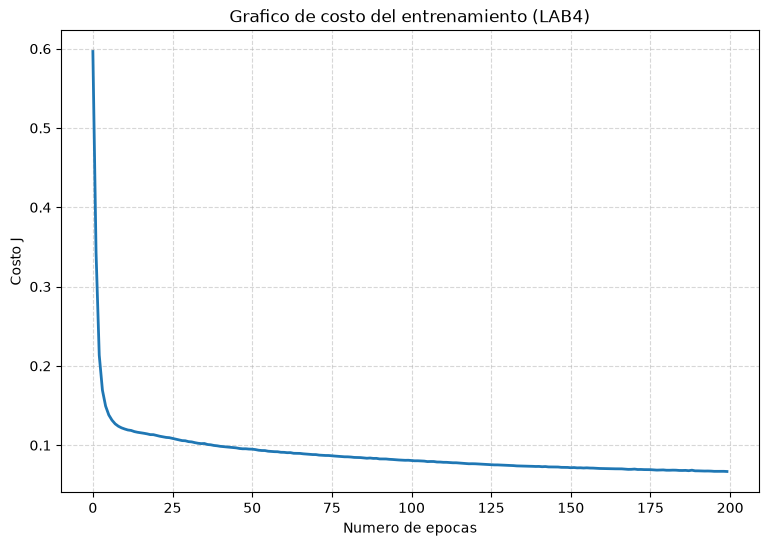

In [9]:
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.title('Grafico de costo del entrenamiento (LAB4)')
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.savefig('costo.png')
pyplot.show()

## 8. Métricas de clasificación

In [10]:
def evaluar(loader, model, nombre):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            logits = model(x_b.to(device))
            preds = (torch.sigmoid(logits) >= 0.5).float()
            y_true.extend(y_b.numpy().ravel())
            y_pred.extend(preds.cpu().numpy().ravel())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"[{nombre}] Accuracy = {acc:.4f} | Precision = {prec:.4f} | Recall = {rec:.4f} | F1 = {f1:.4f}")
    return y_true, y_pred

y_true_train, y_pred_train = evaluar(train_loader, model, "Entrenamiento")
y_true_test, y_pred_test = evaluar(test_loader, model, "Prueba")

[Entrenamiento] Accuracy = 0.9782 | Precision = 0.9838 | Recall = 0.9724 | F1 = 0.9781
[Prueba] Accuracy = 0.9686 | Precision = 0.9768 | Recall = 0.9602 | F1 = 0.9684


## 9. Guardar los pesos del modelo

In [12]:
PATH = './checkpoint.pt'
torch.save(model.state_dict(), PATH)
print("Pesos guardados en:", PATH)

Pesos guardados en: ./checkpoint.pt


## 10. Cargar el modelo y predecir

In [13]:
model_loaded = RedClasificacion(n_features).to(device)
model_loaded.load_state_dict(torch.load(PATH))
model_loaded.eval()

# Predicción de las primeras 5 muestras de prueba
x_sample = torch.from_numpy(X_test[:5])
with torch.no_grad():
    probs = torch.sigmoid(model_loaded(x_sample.to(device))).cpu().numpy().ravel()
    preds = (probs >= 0.5).astype(int)

print("Predicciones sobre las primeras 5 muestras de prueba:")
for i in range(5):
    print(f"  Real: {int(y_test[i])} | Predicho: {preds[i]} | Prob: {probs[i]:.4f}")

Predicciones sobre las primeras 5 muestras de prueba:
  Real: 0 | Predicho: 0 | Prob: 0.0003
  Real: 0 | Predicho: 0 | Prob: 0.0006
  Real: 0 | Predicho: 0 | Prob: 0.0000
  Real: 1 | Predicho: 1 | Prob: 0.9993
  Real: 1 | Predicho: 1 | Prob: 1.0000
